<a href="https://colab.research.google.com/github/lukalklikadze/walmart-sales-forecasting/blob/main/notebooks/sarima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ══ Bootstrap ══
!pip -q install mlflow kaggle statsmodels

!git clone -q https://github.com/lukalklikadze/walmart-sales-forecasting.git /content/repo \
    2>/dev/null || (cd /content/repo && git pull -q)
import sys; sys.path.append("/content/repo")

from src.config import setup_env, DATA_DIR, KAGGLE_COMP
print("MLflow →", setup_env())

import os, glob, zipfile, subprocess
os.makedirs(DATA_DIR, exist_ok=True)
subprocess.run(["kaggle","competitions","download","-c",KAGGLE_COMP,"-p",DATA_DIR,"--force"], check=True)
with zipfile.ZipFile(os.path.join(DATA_DIR, KAGGLE_COMP + ".zip")) as z: z.extractall(DATA_DIR)
for inner in glob.glob(os.path.join(DATA_DIR, "*.csv.zip")):
    with zipfile.ZipFile(inner) as z: z.extractall(DATA_DIR)

from src.data import load_raw
train, test, stores, features = load_raw()
print("train:", train.shape, "| test:", test.shape)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

# SARIMA - theory write-up (no training)

We didn't train SARIMA (reasons below), but it's the classic statistics model for exactly
this kind of data, so we cover it as theory.

## The idea in short

ARIMA predicts a series from its own past: recent values (the AR part), recent prediction
errors (the MA part), and it works on differenced data (the I part) so that trends don't
break the assumptions. SARIMA extends this with seasonal versions of the same components
that repeat at a fixed season length. For weekly data with a yearly cycle the season length
is 52: on top of the recent weeks, the model also looks at the same week one year ago and at
how wrong it was one year ago.

## Why this matches our data

The seasonal part is basically the "compare with the same week last year" idea, which is the
single strongest signal we found in this dataset. Our lag_52 / lag_104 features do the same
thing by hand for the tree models.

A quick way to check that the yearly seasonality is really there: the autocorrelation (ACF)
plot of the raw series shows a clear spike at lag 52, and after subtracting the value from 52
weeks ago the spike disappears. That's exactly what our data shows below.

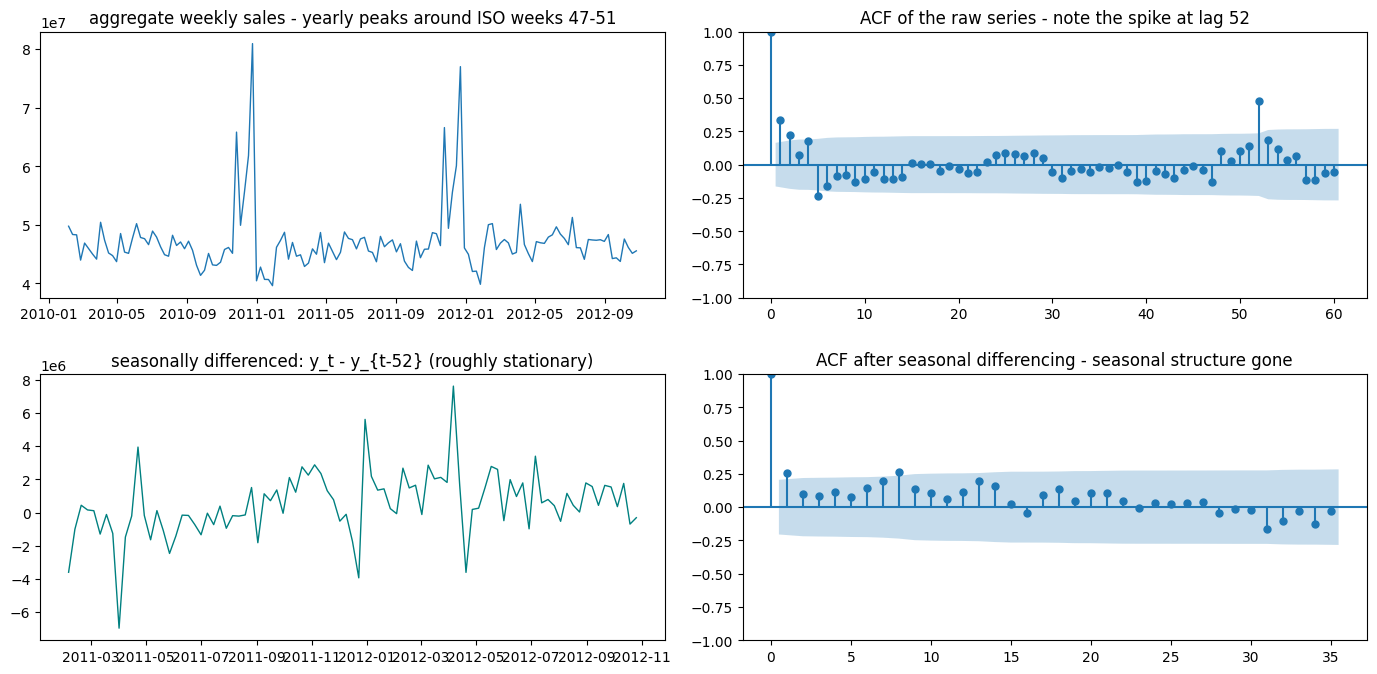

In [2]:
# just an illustration of the seasonal structure - nothing is trained here
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

total = train.groupby("Date")["Weekly_Sales"].sum().sort_index()
sdiff = total.diff(52).dropna()

fig, ax = plt.subplots(2, 2, figsize=(14, 7))
ax[0, 0].plot(total.index, total.values, lw=1)
ax[0, 0].set_title("aggregate weekly sales - yearly peaks around ISO weeks 47-51")
plot_acf(total, lags=60, ax=ax[0, 1])
ax[0, 1].set_title("ACF of the raw series - note the spike at lag 52")
ax[1, 0].plot(sdiff.index, sdiff.values, lw=1, color="teal")
ax[1, 0].set_title("seasonally differenced: y_t - y_{t-52} (roughly stationary)")
plot_acf(sdiff, lags=35, ax=ax[1, 1])
ax[1, 1].set_title("ACF after seasonal differencing - seasonal structure gone")
plt.tight_layout(); plt.show()

## Why we skipped training it

1. SARIMA is one model per series, and we have 3331 (Store, Dept) series. Fits with a season
   length of 52 are slow on their own, so any parameter search multiplied by 3331 series
   turns into days of compute.
2. We only have 143 weeks of data, less than 3 full yearly cycles - too little to estimate
   the seasonal parameters reliably, especially on the many short and sparse series.
3. Each SARIMA sees only its own series. XGBoost and N-BEATS learn across all series at once,
   which matters a lot when most series are thin.
4. Holiday effects (weighted 5x by the metric) would need extra per-series regressors, so
   we'd be rebuilding our calendar features 3331 times.

So SARIMA stays as the theory benchmark. Its main idea is in the project anyway: the
lag_52/53/104 features are the same "look one year back" trick, and they took XGBoost from
~8.7k to ~1.8k WMAE.